<hr>
<div>
<h2>Initialize Modeling Environment</h2>
<p>Initializes the shared imports, plotting style, and data access used throughout section 03. The embedding model runs locally; the only API use is naming topics, and those names are cached in <code>cache/topic_labels.json</code> so the notebook reruns without a key.</p>
</div>

In [1]:
# Standard Library
import json
import os
import sys
import warnings
from pathlib import Path
from typing import Literal

# The shared environment's TensorFlow can't load with its protobuf version; umap imports it
# optionally, so it's marked unavailable before umap and BERTopic load.
sys.modules['tensorflow'] = None
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bertopic import BERTopic
from hdbscan import HDBSCAN
from pydantic import BaseModel, Field
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from umap import UMAP
from IPython.display import display

sys.path.insert(0, 'src')
from retention import data, features as F

warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 120)

In [2]:
# Plotting Theme and Color Palette
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

In [3]:
# Output Helpers & Constants
OUTPUTS = Path('outputs')
CACHE = Path('cache')
CACHE.mkdir(exist_ok = True)
SEED = 20260921
N_MONTHS = 24
EMBEDDING_MODEL = 'all-MiniLM-L6-v2'
LABEL_MODEL = 'gpt-4o-mini'
CATEGORIES = ['price', 'network', 'device', 'service', 'moving', 'routine']
CATEGORY_COLORS = dict(zip(CATEGORIES, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#c3c2b7']))
REASON_TO_CATEGORY = {'price': 'price', 'network': 'network', 'device': 'device', 'service': 'service', 'relocation': 'moving'}
CODE_TO_CATEGORY = {'billing': 'price', 'network': 'network', 'device': 'device', 'service': 'service', 'account': 'moving'}
OFFERS = ['discount', 'device', 'data']


def load_output(name):
    return pd.read_parquet(OUTPUTS / f'{name}.parquet')


def save_output(df, name):

    path = OUTPUTS / f'{name}.parquet'
    df.to_parquet(path, index = False)

    return path

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>03 · Churn Reasons</h1>
<p><strong>Purpose:</strong> Reads the care notes to find why customers would leave. Section 02 found that most of the targeting it couldn't do depends on each customer's hidden reason, which the rep's reason codes reveal only partly; the notes are the other source.</p>
<p><strong>Architecture:</strong> Unsupervised first, so the method would work on a carrier's real notes with no labels: embed each note, cluster the embeddings into topics, and have a language model name each topic and map it to a retention category. Only then is the answer key used, to measure how often the categories are right.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Why</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1 · Care notes</td><td style="text-align: left; vertical-align: top;">6,000 notes and the accounts they cover</td><td style="text-align: left; vertical-align: top;">What the notes can and can't reach</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2 · Embeddings</td><td style="text-align: left; vertical-align: top;">Sentence embeddings (all-MiniLM-L6-v2, local)</td><td style="text-align: left; vertical-align: top;">Notes with similar meaning land close together</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3 · Topics</td><td style="text-align: left; vertical-align: top;">BERTopic: UMAP, HDBSCAN, and c-TF-IDF keywords</td><td style="text-align: left; vertical-align: top;">Groups of notes about the same thing</td></tr>
<tr><td style="text-align: left; vertical-align: top;">4 · Naming topics</td><td style="text-align: left; vertical-align: top;">gpt-4o-mini with structured output</td><td style="text-align: left; vertical-align: top;">A name and a retention category per topic</td></tr>
<tr><td style="text-align: left; vertical-align: top;">5 · Validation</td><td style="text-align: left; vertical-align: top;">Categories against the answer key and the rep's codes</td><td style="text-align: left; vertical-align: top;">How often the notes are right, and whether they beat the codes</td></tr>
<tr><td style="text-align: left; vertical-align: top;">6 · Reasons and targeting</td><td style="text-align: left; vertical-align: top;">Account reasons against true uplift, tonight's batch</td><td style="text-align: left; vertical-align: top;">Whether knowing the reason would change who gets which offer</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>1 · Care Notes</h2>
<p><strong>Purpose:</strong> Describes the notes: how many accounts they cover, when they were written, and how many of tonight's accounts have one.</p>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Notes reach few accounts.</strong> 6,000 notes cover 5,707 accounts, and 5,487 of tonight's 75,301 accounts (7.3%). Most customers never generate one; whatever the notes reveal, it is about a minority of the base.</li>
<li style="margin-bottom: 0.7em;"><strong>They're recent and short.</strong> 93% were written in months 13–24, with a median of 46 words, in rep shorthand or short plain sentences.</li>
</ol>
</div>

In [4]:
# Load Care Notes
notes = data.load('care_notes')
contacts = data.load('care_contacts')
tonight = data.load('scoring_snapshot')[['account_id']]

coverage = pd.DataFrame({
    'notes': [len(notes)],
    'accounts with a note': [notes['account_id'].nunique()],
    'notes from months 13–24': [notes['month'].ge(13).mean()],
    'tonight\'s accounts with a note': [tonight['account_id'].isin(notes['account_id']).sum()],
    'share of tonight\'s batch': [tonight['account_id'].isin(notes['account_id']).mean()],
    'median words per note': [notes['text'].str.split().str.len().median()],
})
display(coverage.style.format({'notes': '{:,}', 'accounts with a note': '{:,}', 'notes from months 13–24': '{:.0%}',
                               'tonight\'s accounts with a note': '{:,}', 'share of tonight\'s batch': '{:.1%}', 'median words per note': '{:.0f}'}))
for text in notes.sample(3, random_state = SEED)['text']:
    print('·', text)

,notes,accounts with a note,notes from months 13–24,tonight's accounts with a note,share of tonight's batch,median words per note
0,"6,000","5,707",93%,"5,487",7.3%,46


· Cust called in frustrated w/ dropped calls & weak signal at home. Rep verified acct details; noted bill increase of 25% recently. Advised cust to check for tower issues & offered to escalate for coverage review; noted cust's phone is 56 months old, suggested considering upgrade if signal issues persist.
· Cust called, expressed concern about recent bill, asked why it seems higher than expected. Rep reviewed acct – confirmed +0% increase w/ no recent changes to plan or features. Suggested cust check for any promotional offers elsewhere but noted existing plan is competitive for usage; offered to review options if cust interested.
· Cust inquired about options for newer devices; mentioned issues w/ phone performance and battery life. Rep confirmed current device age at 64 mos, highlighted upgrade eligibility on acct. Provided info on latest models and potential trade-in value for existing device.


<hr>
<div>
<h2>2 · Embeddings</h2>
<p><strong>Purpose:</strong> Turns each note into a 384-number vector that places notes with similar meaning close together, the input to the topic model and, in section 05, to the agent's note retrieval.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Model.</strong> <code>all-MiniLM-L6-v2</code>, a small general-purpose sentence model that runs on a laptop in seconds. Notes never leave the machine for this step.</li>
<li style="margin-bottom: 0.7em;"><strong>Normalized.</strong> Vectors are scaled to length 1, so distance measures only the angle between notes: what they're about, not how long they are.</li>
</ol>
</div>

In [5]:
# Embed Notes
import logging
import transformers
logging.getLogger('sentence_transformers').setLevel(logging.ERROR)
transformers.logging.set_verbosity_error()
encoder = SentenceTransformer(EMBEDDING_MODEL)
embeddings = encoder.encode(notes['text'].tolist(), batch_size = 64, show_progress_bar = False, normalize_embeddings = True)
np.save(OUTPUTS / 'note_embeddings.npy', embeddings)
print(f'{embeddings.shape[0]:,} notes × {embeddings.shape[1]} dimensions')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

6,000 notes × 384 dimensions


<hr>
<div>
<h2>3 · Topics</h2>
<p><strong>Purpose:</strong> Clusters the notes into topics and describes each by its most distinctive words.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>UMAP.</strong> Reduces the embeddings to 5 dimensions, keeping each note's 15 nearest neighbors together, since clustering works poorly in 384.</li>
<li style="margin-bottom: 0.7em;"><strong>HDBSCAN, Fine-Grained.</strong> Clusters of at least 40 notes, choosing the smallest stable clusters ("leaf"). The coarser default merged most notes into one cluster held together by the reps' shared phrasing ("cust called", "rep reviewed") rather than by what customers raised; fine topics are merged later by category.</li>
<li style="margin-bottom: 0.7em;"><strong>Outliers Reassigned.</strong> Notes HDBSCAN leaves unclustered are assigned to the topic whose center is nearest in embedding space.</li>
<li style="margin-bottom: 0.7em;"><strong>Keywords.</strong> c-TF-IDF: words frequent in a topic and rare elsewhere. Rep boilerplate ("cust", "rep", "reviewed", "confirmed") is excluded so the keywords describe the customer's issue.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>34 fine-grained topics.</strong> 35% of notes fell outside any cluster at first and were reassigned to the nearest topic.</li>
<li style="margin-bottom: 0.7em;"><strong>Topics describe issues, not reasons.</strong> Keywords read like the calls: promotions and cheaper offers, weak signal at home, old phones and battery life, long hold times, coverage in a new city, and routine requests such as adding a line or updating an address.</li>
</ol>
</div>

In [6]:
# Fit Topic Model
BOILERPLATE = {'cust', 'customer', 'rep', 'reviewed', 'called', 'call', 'account', 'acct', 'confirmed', 'noted', 'advised',
               'offered', 'mentioned', 'discussed', 'provided', 'inquired', 'expressed', 'regarding', 're', 'w'}
topic_model = BERTopic(
    umap_model = UMAP(n_neighbors = 15, n_components = 5, min_dist = 0.0, metric = 'cosine', random_state = SEED),
    hdbscan_model = HDBSCAN(min_cluster_size = 40, metric = 'euclidean', cluster_selection_method = 'leaf', prediction_data = True),
    vectorizer_model = CountVectorizer(stop_words = list(ENGLISH_STOP_WORDS | BOILERPLATE), ngram_range = (1, 2), min_df = 5),
)
texts = notes['text'].tolist()
initial_topics, _ = topic_model.fit_transform(texts, embeddings)
topics = topic_model.reduce_outliers(texts, initial_topics, strategy = 'embeddings', embeddings = embeddings)
topic_model.update_topics(texts, topics = topics, vectorizer_model = topic_model.vectorizer_model)
notes['topic'] = topics

topic_table = pd.DataFrame({
    'topic': sorted(set(topics)),
}).assign(
    notes = lambda d: d['topic'].map(pd.Series(topics).value_counts()),
    keywords = lambda d: d['topic'].map(lambda t: ', '.join(w for w, _ in topic_model.get_topic(t)[:8])),
)
print(f'{len(topic_table)} topics · {np.mean(np.array(initial_topics) == -1):.0%} of notes were outliers before reassignment')
display(topic_table.head(12))

2026-09-21 18:51:29,435 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


34 topics · 35% of notes were outliers before reassignment


,topic,notes,keywords
0,0,473,"promotions, recent, current, offers, available, cheaper, plan, lower"
1,1,416,"signal, home, weak, weak signal, calls weak, signal home, network, dropped calls"
2,2,220,"line, member, additional, request, existing, process, processed, unlimited"
3,3,281,"dropped, calls, dropped calls, increase, issue, ongoing, recent, investigation"
4,4,205,"payment, set, requested, request, plan, lines, date, unlimited"
5,5,203,"address, update, billing, updated, raised, processed, verified, successfully"
6,6,225,"coverage, service, new, city, coverage new, new city, maps, coverage maps"
7,7,223,"upset, offers, cheaper, cheaper offers, size, seeing, seeing cheaper, upset size"
8,8,225,"cheaper, dropped, calls, dropped calls, recent, dissatisfaction, high, offers"
9,9,230,"times, issue, hold, long, transfers, hold times, multiple, frustrated"


<hr>
<div>
<h2>4 · Naming Topics</h2>
<p><strong>Purpose:</strong> Has a language model read each topic's keywords and example notes, then give it a short name and one of six retention categories, so every note, and through its notes every account, gets a reason the rest of the pipeline can use.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Categories.</strong> Price, network, device, service, moving, and routine (a contact that says nothing about leaving). These match the carrier's offer logic: a discount addresses price, a device credit addresses the phone, and nothing addresses a move.</li>
<li style="margin-bottom: 0.7em;"><strong>Structured Output.</strong> The model must answer in a fixed schema: a name of at most six words and a category from the list. There is no free text to parse, and no category outside the six.</li>
<li style="margin-bottom: 0.7em;"><strong>Evidence Given.</strong> The topic's 10 keywords and 3 of its most representative notes. The model names topics; it never sees account data or the answer key.</li>
<li style="margin-bottom: 0.7em;"><strong>Cached.</strong> Names are saved with the keywords they were given; a rerun with the same topics makes no API calls.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Every topic got a category.</strong> Price 1,660 notes, network 1,771, device 1,148, service 468, moving 293, and routine 660. Several fine topics share a category, the merge the coarse clustering couldn't do.</li>
<li style="margin-bottom: 0.7em;"><strong>Some calls are judgment calls.</strong> The model put payment-arrangement requests under price and “dropped calls and a bill increase” under network. Both are defensible readings of the words, and both show up as errors in section 5.</li>
</ol>
</div>

In [7]:
# Name Topics with an LLM
class TopicLabel(BaseModel):
    name: str = Field(description = 'A short name for what these customers raised, at most six words')
    category: Literal['price', 'network', 'device', 'service', 'moving', 'routine'] = Field(
        description = 'price: cost of the bill or cheaper offers; network: coverage, signal, dropped calls; device: the phone itself or upgrades; '
                      'service: unresolved problems or poor support; moving: relocating; routine: an ordinary request with no sign of leaving')


LABEL_CACHE = CACHE / 'topic_labels.json'
cached = json.loads(LABEL_CACHE.read_text()) if LABEL_CACHE.exists() else {}


def label_prompt(topic):
    examples = '\n'.join(f'- {doc}' for doc in topic_model.get_representative_docs(topic)[:3])
    return (f'These are internal care notes from a US wireless carrier, grouped into one topic.\n'
            f'Distinctive words: {topic_table.set_index("topic").at[topic, "keywords"]}\n'
            f'Representative notes:\n{examples}\n\n'
            f'Name what these customers raised, and choose the retention category it belongs to.')


prompts = {int(t): label_prompt(t) for t in topic_table['topic']}
missing = {t: p for t, p in prompts.items() if cached.get(p) is None}
if missing:
    from openai import OpenAI
    key = os.environ.get('OPENAI_API_KEY') or next(
        (line.split('=', 1)[1].strip().strip('"\'') for line in Path('../../selected-work/.env').read_text().splitlines()
         if line.strip().startswith('OPENAI_API_KEY')), None)
    client = OpenAI(api_key = key)
    for topic, prompt in missing.items():
        response = client.chat.completions.parse(
            model = LABEL_MODEL, temperature = 0, response_format = TopicLabel,
            messages = [{'role': 'user', 'content': prompt}])
        cached[prompt] = response.choices[0].message.parsed.model_dump()
    LABEL_CACHE.write_text(json.dumps(cached, indent = 1))
print(f'{len(prompts) - len(missing)} topic names from the cache · {len(missing)} from {LABEL_MODEL}')

topic_table['name'] = topic_table['topic'].map(lambda t: cached[prompts[int(t)]]['name'])
topic_table['category'] = topic_table['topic'].map(lambda t: cached[prompts[int(t)]]['category'])
notes = notes.merge(topic_table[['topic', 'name', 'category']], on = 'topic')
display(topic_table[['topic', 'notes', 'name', 'category', 'keywords']])

34 topic names from the cache · 0 from gpt-4o-mini


,topic,notes,name,category,keywords
0,0,473,Concerns Over Bill Increases,price,"promotions, recent, current, offers, available, cheaper, plan, lower"
1,1,416,Weak Signal and Dropped Calls,network,"signal, home, weak, weak signal, calls weak, signal home, network, dropped calls"
2,2,220,Adding a Line for Family Member,routine,"line, member, additional, request, existing, process, processed, unlimited"
3,3,281,Dropped Calls and Bill Increase,network,"dropped, calls, dropped calls, increase, issue, ongoing, recent, investigation"
4,4,205,Payment Arrangement Requests,price,"payment, set, requested, request, plan, lines, date, unlimited"
5,5,203,Billing Address Update,routine,"address, update, billing, updated, raised, processed, verified, successfully"
6,6,225,Coverage in New City,moving,"coverage, service, new, city, coverage new, new city, maps, coverage maps"
7,7,223,Upset About Bill Size and Cheaper Offers,price,"upset, offers, cheaper, cheaper offers, size, seeing, seeing cheaper, upset size"
8,8,225,Dissatisfaction with Bill and Service,price,"cheaper, dropped, calls, dropped calls, recent, dissatisfaction, high, offers"
9,9,230,Frustration Over Ongoing Issues,service,"times, issue, hold, long, transfers, hold times, multiple, frustrated"


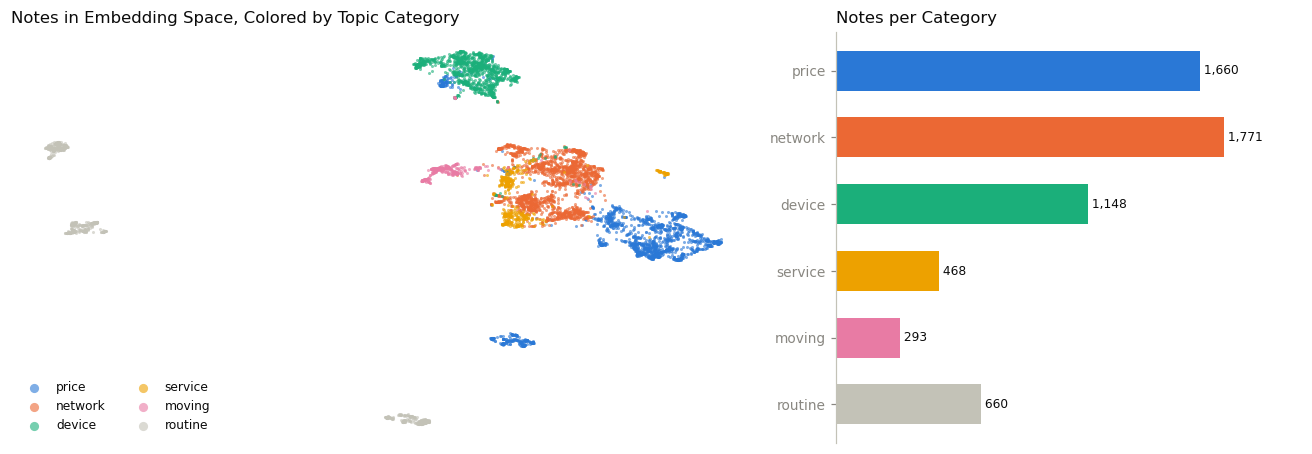

In [8]:
# Plot: Notes by Topic and Category
by_category = topic_table.groupby('category')['notes'].sum().reindex(CATEGORIES).fillna(0)
layout = UMAP(n_neighbors = 15, n_components = 2, min_dist = 0.1, metric = 'cosine', random_state = SEED).fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize = (12, 4.2), gridspec_kw = {'width_ratios': [1.6, 1]})
for category in CATEGORIES:
    mask = (notes.sort_values('note_id')['category'] == category).to_numpy()
    axes[0].scatter(layout[mask, 0], layout[mask, 1], s = 4, alpha = 0.6, color = CATEGORY_COLORS[category], label = category, linewidths = 0)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].spines[['left', 'bottom']].set_visible(False)
axes[0].set_title('Notes in Embedding Space, Colored by Topic Category', loc = 'left')
axes[0].legend(frameon = False, fontsize = 8, markerscale = 3, loc = 'lower left', ncol = 2)

axes[1].barh(by_category.index[::-1], by_category.values[::-1], color = [CATEGORY_COLORS[c] for c in by_category.index[::-1]], height = 0.6)
for i, v in enumerate(by_category.values[::-1]):
    axes[1].text(v, i, f' {v:,.0f}', va = 'center', fontsize = 8, color = INK)
axes[1].set_xlim(0, by_category.max() * 1.2)
axes[1].set_xticks([])
axes[1].spines['bottom'].set_visible(False)
axes[1].set_title('Notes per Category', loc = 'left')
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>5 · Validation</h2>
<p><strong>Purpose:</strong> Measures, against the answer key, how often a note's category is right, both about the note itself and about the account's real reason for leaving, and compares the notes with the rep's reason codes.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Two Questions.</strong> Is the category right about what the note says (its topic, in the answer key)? And is it right about why the account would leave (its hidden reason)? They differ because about a quarter of notes are about some other issue than the account's reason, and 14% are routine.</li>
<li style="margin-bottom: 0.7em;"><strong>Account Reason from Notes.</strong> The most common non-routine category among an account's notes; ties go to the latest note.</li>
<li style="margin-bottom: 0.7em;"><strong>Account Reason from Codes.</strong> The most common reason code among the account's care contacts through month 24, mapped to the same categories (billing to price, account changes to moving).</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The notes read the call well.</strong> 74% of notes get their own topic's category, and over 90% for price, device, and moving. Service is the weak spot: 56% of service notes are read as network, because customers describing an unresolved problem often name dropped calls as the problem.</li>
<li style="margin-bottom: 0.7em;"><strong>They read the customer less well.</strong> The account's reason from its notes is right 52% of the time. About a quarter of calls are about some other issue than the reason a customer would leave, so a single note is a weak witness.</li>
<li style="margin-bottom: 0.7em;"><strong>The rep's codes, added up, do better.</strong> An account's most common reason code across all its contacts is right 90% of the time: each code is noisy, but accounts with notes have many contacts. Where notes and codes agree, 46% of accounts, the reason is right 98% of the time.</li>
</ol>
</div>

In [9]:
# Validate against the Answer Key
truth_notes = data.load_answer_key('truth_notes').set_index('note_id')
truth_accounts = data.load_answer_key('truth_accounts').set_index('account_id')

scored = notes.join(truth_notes, on = 'note_id')
scored['true_topic'] = scored['primary_reason'].map(REASON_TO_CATEGORY).fillna('routine')
scored['true_reason'] = scored['account_id'].map(truth_accounts['reason']).map(REASON_TO_CATEGORY)
non_routine = scored[scored['category'] != 'routine']

note_level = pd.DataFrame({
    'category matches the note\'s topic': [(scored['category'] == scored['true_topic']).mean()],
    'adjusted Rand index, topics vs note topics': [adjusted_rand_score(scored['true_topic'], scored['topic'])],
    'non-routine category matches the account\'s reason': [(non_routine['category'] == non_routine['true_reason']).mean()],
})
display(note_level.style.format({c: '{:.0%}' for c in note_level.columns if 'matches' in c} | {'adjusted Rand index, topics vs note topics': '{:.2f}'}))


def account_reason(rows, category_column, month_column = 'month'):
    rows = rows.sort_values(month_column)
    counts = rows.groupby(['account_id', category_column]).agg(n = (month_column, 'size'), last = (month_column, 'max')).reset_index()
    return counts.sort_values(['account_id', 'n', 'last']).groupby('account_id').tail(1).set_index('account_id')[category_column]


from_notes = account_reason(non_routine, 'category')
code_rows = contacts.assign(code_category = contacts['reason_code'].map(CODE_TO_CATEGORY))
from_codes = account_reason(code_rows, 'code_category')
compare = pd.DataFrame({'notes': from_notes}).join(from_codes.rename('codes'))
compare['truth'] = compare.index.map(truth_accounts['reason']).map(REASON_TO_CATEGORY)
account_level = pd.DataFrame({
    'accounts': [len(compare)],
    'reason from notes is right': [(compare['notes'] == compare['truth']).mean()],
    'reason from codes is right': [(compare['codes'] == compare['truth']).mean()],
    'right when notes and codes agree': [(compare['notes'] == compare['truth'])[compare['notes'] == compare['codes']].mean()],
    'notes and codes agree': [(compare['notes'] == compare['codes']).mean()],
})
display(account_level.style.format({'accounts': '{:,}'} | {c: '{:.0%}' for c in account_level.columns if c != 'accounts'})
        .set_caption('Accounts with at least one non-routine note'))

,category matches the note's topic,"adjusted Rand index, topics vs note topics",non-routine category matches the account's reason
0,74%,0.22,52%


,accounts,reason from notes is right,reason from codes is right,right when notes and codes agree,notes and codes agree
0,"5,108",52%,90%,98%,46%


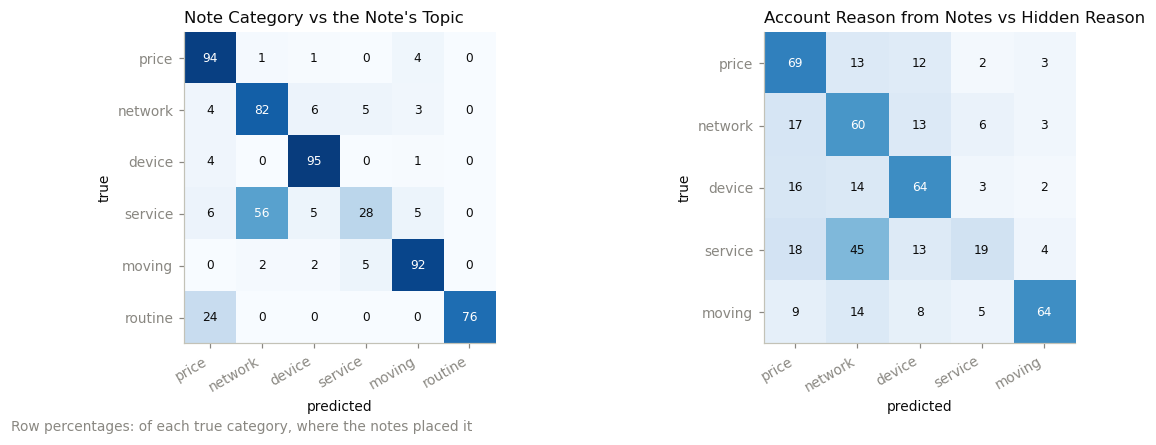

In [10]:
# Plot: Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize = (11, 4.2))
panels = [(scored['true_topic'], scored['category'], 'Note Category vs the Note\'s Topic', CATEGORIES),
          (compare['truth'], compare['notes'], 'Account Reason from Notes vs Hidden Reason', CATEGORIES[:5])]
for ax, (true, predicted, title, labels) in zip(axes, panels):
    matrix = confusion_matrix(true, predicted, labels = labels, normalize = 'true') * 100
    ax.imshow(matrix, cmap = 'Blues', vmin = 0, vmax = 100)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f'{matrix[i, j]:.0f}', ha = 'center', va = 'center', fontsize = 8, color = SURFACE if matrix[i, j] > 55 else INK)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation = 30, ha = 'right')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.set_title(title, loc = 'left')
fig.suptitle('Row percentages: of each true category, where the notes placed it', fontsize = 9, color = MUTED, x = 0.01, ha = 'left', y = 0.02)
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>6 · Reasons and Targeting</h2>
<p><strong>Purpose:</strong> Asks whether knowing an account's reason from its notes would change who should get which offer, using tonight's accounts that have notes and their true uplift from the answer key.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>True Uplift by Reason.</strong> For tonight's accounts with a non-routine note, the average true 90-day uplift of each offer, grouped by the reason their notes point to.</li>
<li style="margin-bottom: 0.7em;"><strong>A Simple Adjustment.</strong> Section 02's uplift estimates, changed only by the account's reason: no offer for customers who are moving; the discount and data upgrade doubled for price; the device credit doubled for device. Compared with section 02 alone by the true uplift held in the top fifth of each offer's ranking, among accounts with notes.</li>
<li style="margin-bottom: 0.7em;"><strong>Three Sources of the Reason.</strong> The notes; the rep's codes; and both, using a reason only where they agree.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The reason predicts which offer works.</strong> Among tonight's noted accounts, those whose notes point to price have a true discount uplift of 1.11 points, over twice any other group's; those pointing to device have a device-credit uplift of 0.98 points. The “moving” label is less reliable: those accounts still show a 0.40-point discount uplift, so zeroing their offers costs something.</li>
<li style="margin-bottom: 0.7em;"><strong>Knowing the reason sharpens targeting.</strong> Adjusting section 02's estimates by the note reason lifts the top fifth's share of the true benefit from 2.78 to 2.97 times for the discount, 1.78 to 2.03 for the device credit, and 1.31 to 1.64 for the data upgrade.</li>
<li style="margin-bottom: 0.7em;"><strong>The codes sharpen it more.</strong> The same adjustment with the account's most common code reaches 3.14, 2.64, and 1.86 times. Section 02 used the codes only as 6-month indicators; the full-history majority code is the stronger signal, and it exists for far more accounts than the notes.</li>
</ol>
</div>

In [11]:
# Compare True Uplift by Note Reason
uplift_scores = load_output('uplift_scores').set_index('account_id')
truth_tonight = data.load_answer_key('truth_potential_outcomes').set_index('account_id')
noted = pd.DataFrame({'reason': from_notes}).join(uplift_scores, how = 'inner').join(truth_tonight.filter(like = 'p_churn_90'))
for offer in OFFERS:
    noted[f'true_{offer}'] = noted['p_churn_90_control'] - noted[f'p_churn_90_{offer}']
by_reason = noted.groupby('reason')[[f'true_{o}' for o in OFFERS]].mean().mul(100).reindex(CATEGORIES[:5])
by_reason.insert(0, 'accounts', noted['reason'].value_counts().reindex(CATEGORIES[:5]))
display(by_reason.rename(columns = {f'true_{o}': f'true {o} uplift, points' for o in OFFERS})
        .style.format({'accounts': '{:,.0f}'} | {f'true {o} uplift, points': '{:+.2f}' for o in OFFERS}))

BOOST = {'discount': ['price'], 'device': ['device'], 'data': ['price']}
noted['code_reason'] = noted.index.map(from_codes)
SOURCES = {
    'note reasons': noted['reason'],
    'code reasons': noted['code_reason'],
    'notes and codes, where they agree': noted['reason'].where(noted['reason'] == noted['code_reason']),
}


def adjust(base, reason, offer):
    adjusted = base.where(reason != 'moving', 0.0)
    return adjusted.where(~reason.isin(BOOST[offer]), adjusted * 2)


def top_fifth(true, ranking):
    return true.loc[ranking.sort_values(ascending = False).index[:len(true) // 5]].mean() / true.mean()


results = {}
for offer in OFFERS:
    base, true = noted[f'uplift_{offer}'], noted[f'true_{offer}']
    results[offer] = {'section 02 alone': top_fifth(true, base)}
    results[offer] |= {f'with {name}': top_fifth(true, adjust(base, reason, offer)) for name, reason in SOURCES.items()}
    results[offer]['ceiling (true uplift)'] = top_fifth(true, true)
display(pd.DataFrame(results).style.format('{:.2f}×').set_caption(f'True uplift of the top fifth ÷ average, {len(noted):,} of tonight\'s accounts with a non-routine note'))

,accounts,"true discount uplift, points","true device uplift, points","true data uplift, points"
reason,,,,
price,"1,551",+1.11,+0.42,+0.30
network,"1,621",+0.45,+0.23,+0.13
device,"1,068",+0.32,+0.98,+0.09
service,411,+0.48,+0.28,+0.08
moving,255,+0.40,+0.26,+0.07


,discount,device,data
section 02 alone,2.78×,1.78×,1.31×
with note reasons,2.97×,2.03×,1.64×
with code reasons,3.14×,2.64×,1.86×
"with notes and codes, where they agree",3.01×,2.29×,1.62×
ceiling (true uplift),3.98×,4.24×,3.90×


<hr>
<div>
<h2>7 · Handoff</h2>
<p><strong>Purpose:</strong> Saves each note's topic and category, and each account's reason, for the optimizer (section 04) and the agent (section 05), which cites the notes when it drafts outreach.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Files.</strong> <code>outputs/note_topics.parquet</code> (note, topic, name, category), <code>outputs/account_reasons.parquet</code> (account, reason from notes, reason from codes, number of notes), and <code>outputs/note_embeddings.npy</code>.</li>
</ol>
</div>

In [12]:
# Save Note Topics and Account Reasons
print(save_output(notes[['note_id', 'account_id', 'month', 'topic', 'name', 'category']], 'note_topics'))
reasons = (pd.DataFrame({'reason_from_notes': from_notes})
           .join(from_codes.rename('reason_from_codes'), how = 'outer')
           .join(notes.groupby('account_id').size().rename('notes'), how = 'left'))
reasons['notes'] = reasons['notes'].fillna(0).astype(int)
print(save_output(reasons.rename_axis('account_id').reset_index(), 'account_reasons'), f'· {len(reasons):,} accounts')

outputs/note_topics.parquet
outputs/account_reasons.parquet · 77,563 accounts


<hr>
<div>
<h2>Section 03 Summary</h2>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>An unsupervised pipeline reads the calls.</strong> Local embeddings, fine-grained BERTopic clusters, and an LLM naming each topic in a fixed schema put 74% of notes in the category of what they're about, over 90% for price, device, and moving, without a single labeled note.</li>
<li style="margin-bottom: 0.7em;"><strong>A call is not a reason.</strong> Customers call about many things, so an account's notes point to its real reason only 52% of the time; its rep codes, added up over every contact, point to it 90% of the time.</li>
<li style="margin-bottom: 0.7em;"><strong>Reasons improve targeting.</strong> Adjusting section 02's uplift by the account's reason puts more of the true benefit in the top fifth of every offer's ranking, most with the codes: up to 3.1 times the average for the discount, against a ceiling of 4.</li>
<li style="margin-bottom: 0.7em;"><strong>What each source is for.</strong> The codes, which cover most accounts, should inform who gets which offer (section 04). The notes, which hold the customer's own words, are what the agent reads when it writes to them (section 05).</li>
</ol>
</div>